# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* None
* None
* None


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [30]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Cargamos los datos:

df = pd.read_csv("data/SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [3]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************

column_names_en = {
    'laufkont'  : 'status',
    'laufzeit'  : 'duration',
    'moral'     : 'credit_history',
    'verw'      : 'purpose',
    'hoehe'     : 'amount',
    'sparkont'  : 'savings',
    'beszeit'   : 'employment_duration',
    'rate'      : 'installment_rate',
    'famges'    : 'personal_status_sex',
    'buerge'    : 'other_debtors',
    'wohnzeit'  : 'present_residence',
    'verm'      : 'property',
    'alter'     : 'age',
    'weitkred'  : 'other_installment_plans',
    'wohn'      : 'housing',
    'bishkred'  : 'number_credits',
    'beruf'     : 'job',
    'pers'      : 'people_liable',
    'telef'     : 'telephone',
    'gastarb'   : 'foreign_worker',
    'kredit'    : 'credit_risk'
}

df.rename(columns=column_names_en, inplace=True)




# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [4]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************


df['credit_risk'] = df['credit_risk'].map({1: 0, 0: 1})



# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**



En Machine Learning, por convención la clase positiva (1) representa el evento de interés que queremos detectar. En el contexto de riesgo crediticio, el evento de interés es el cliente malo (el que no paga), porque:

Es la clase minoritaria (~30% del dataset) y la más costosa de no detectar.
Las métricas como recall, precisión y F1 se calculan por defecto sobre la clase positiva (1). Si dejamos "mal cliente = 0", estaríamos midiendo el desempeño sobre los buenos clientes, que no es lo que nos preocupa.
El costo asimétrico del error: prestarle a alguien que no pagará (falso negativo) es mucho más caro para el banco que negarle el crédito a alguien confiable (falso positivo).

Después de la inversión:

- 1 = mal cliente (riesgo alto) → clase positiva
- 0 = buen cliente (riesgo bajo) → clase negativa


# **Ejercicio 3**

In [6]:
# Ejercicio 3a.
# Realiza una partición con el mismo porcentaje utilizado en el artículo
# de la IEEE que estamos usando en esta actividad para entrenamiento y
# prueba. Muestra además el porcentaje de distribución de las variables
# de salida ytrain y ytest.

# ************* Inlcuye aquí tu código:*****************************


X = df.drop(columns='credit_risk')
y = df['credit_risk']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.2,
    random_state=7,
    stratify=y
)



# *********** Aquí termina la sección de agregar código *************


In [7]:
# Mostremos también las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (800, 20) (800,)
Test X, y (200, 20) (200,)


**Ejercicio 3b.**

  * **Suponiendo que la métrica a monitorear es la exactitud (acccuracy), ¿cuál sería el valor exacto del umbral que nos dice si un modelo está o no subentrenado en este ejercicio?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++


Punto 3b — Umbral de subentrenamiento (accuracy):
Se usa stratify=y para que ambas particiones conserven la misma proporción de clases del dataset original (~70% buenos, ~30% malos).
El umbral de subentrenamiento con accuracy es el desempeño que obtendría un clasificador trivial que siempre predice la clase mayoritaria. Con ~70/30 de distribución:

Umbral = ~70% — si un modelo no supera ese valor de accuracy, está subentrenado, pues un clasificador "tonto" que siempre diga "buen cliente" ya lo alcanzaría sin aprender nada.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 4**

In [8]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas (cuantitativas continuas)
numerical_features = [
    'duration',    # duración del crédito en meses
    'amount',      # monto del crédito
    'age'          # edad del solicitante
]


# Variables ordinales (tienen un orden natural entre categorías)
ordinal_features = [
    'status',                   # estado de la cuenta corriente
    'credit_history',           # historial crediticio
    'savings',                  # saldo en cuenta de ahorros
    'employment_duration',      # tiempo de empleo actual
    'installment_rate',         # tasa de pago a plazos (% del ingreso)
    'present_residence',        # tiempo en residencia actual
    'number_credits',           # número de créditos existentes
    'people_liable'             # número de personas a cargo
]

# Variables nominales (categóricas sin orden: one-hot encoding)
nominal_features = [
    'purpose',                  # propósito del crédito
    'personal_status_sex',      # estado civil y sexo
    'other_debtors',            # otros deudores/garantes
    'property',                 # tipo de propiedad
    'other_installment_plans',  # otros planes de pago a plazos
    'housing',                  # tipo de vivienda
    'job',                      # tipo de trabajo
    'telephone',                # tiene teléfono registrado (binary)
    'foreign_worker'            # es trabajador extranjero (binary)
]

print(f"Numéricas  : {len(numerical_features)}  variables -> {numerical_features}")
print(f"Ordinales  : {len(ordinal_features)} variables -> {ordinal_features}")
print(f"Nominales  : {len(nominal_features)}  variables -> {nominal_features}")
print(f"\nTotal      : {len(numerical_features)+len(ordinal_features)+len(nominal_features)} variables (de 20 features)")

# *********** Aquí termina la sección de agregar código *************

Numéricas  : 3  variables -> ['duration', 'amount', 'age']
Ordinales  : 8 variables -> ['status', 'credit_history', 'savings', 'employment_duration', 'installment_rate', 'present_residence', 'number_credits', 'people_liable']
Nominales  : 9  variables -> ['purpose', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Total      : 20 variables (de 20 features)


# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

=== Estadísticas descriptivas ===


,count,mean,std,min,25%,50%,75%,max
status,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_history,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
savings,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
employment_duration,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
personal_status_sex,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
other_debtors,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0


C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\1668944347.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='credit_risk', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\1668944347.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'])


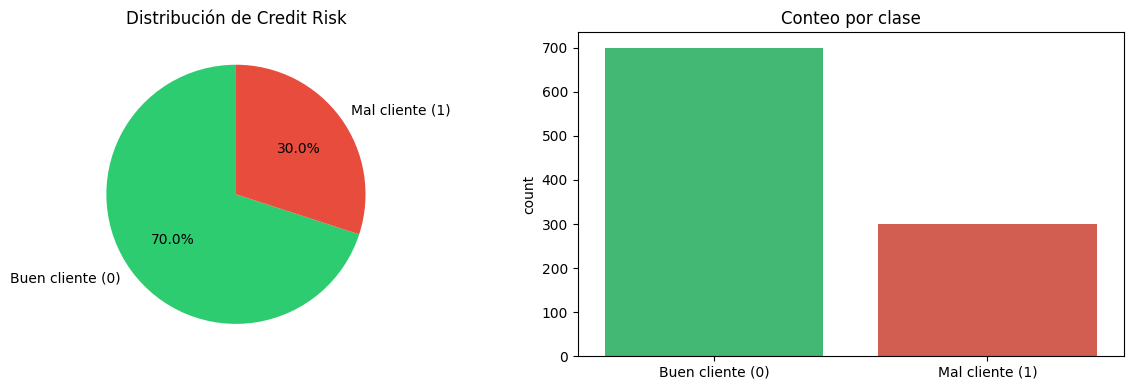

In [11]:
# ************* Inlcuye aquí tu código:*****************************

# Puedes incluir a continuación todas las celdas de código que requieras....

# ── 1. Estadísticas descriptivas generales ──────────────────────
print("=== Estadísticas descriptivas ===")
display(df.describe().T)

# ── 2. Distribución de la variable objetivo ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['credit_risk'].value_counts()
axes[0].pie(counts, labels=['Buen cliente (0)', 'Mal cliente (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribución de Credit Risk')

sns.countplot(x='credit_risk', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'])
axes[1].set_title('Conteo por clase')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

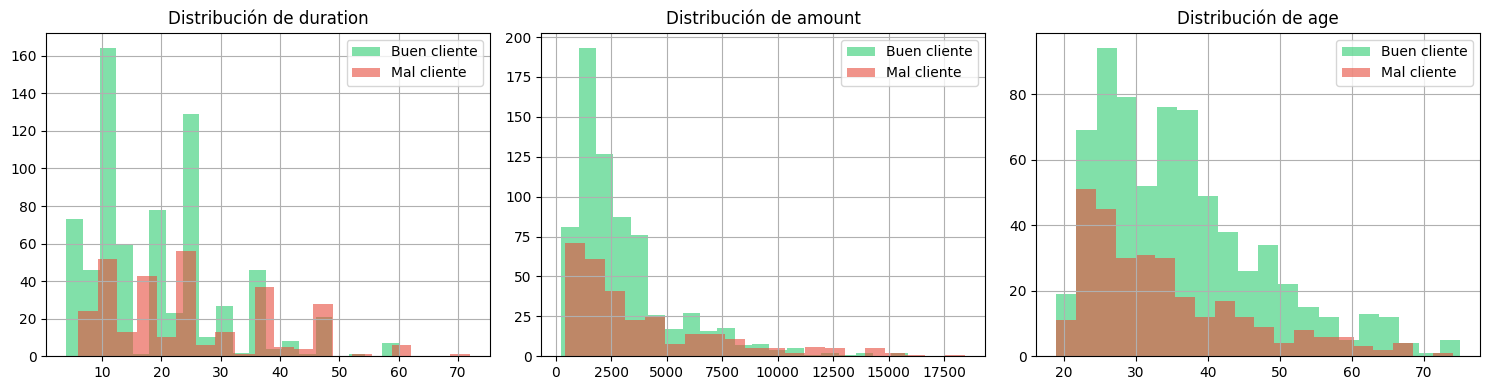

In [12]:
# ── 3. Distribución de variables numéricas por clase ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numerical_features):
    for cls, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'],
                                  ['Buen cliente', 'Mal cliente']):
        df[df['credit_risk'] == cls][col].hist(ax=ax, alpha=0.6,
                                                color=color, label=label, bins=20)
    ax.set_title(f'Distribución de {col}')
    ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\2268977775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_risk', y=col, data=df,
C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\2268977775.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'])
C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\2268977775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_risk', y=col, data=df,
C:\Users\Cristian-Paz\AppData\Local\Temp\ipykernel_10104\2268977775.py:6: UserWarning: set_ticklabels() should only be used with

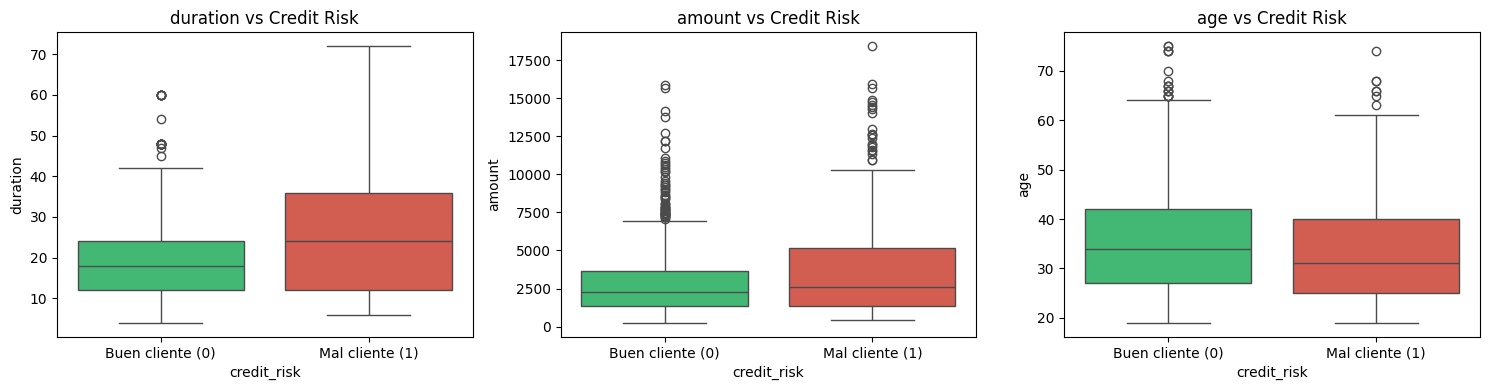

In [13]:
# ── 4. Boxplots: variables numéricas vs credit_risk ───────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numerical_features):
    sns.boxplot(x='credit_risk', y=col, data=df,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Buen cliente (0)', 'Mal cliente (1)'])
    ax.set_title(f'{col} vs Credit Risk')
plt.tight_layout()
plt.show()

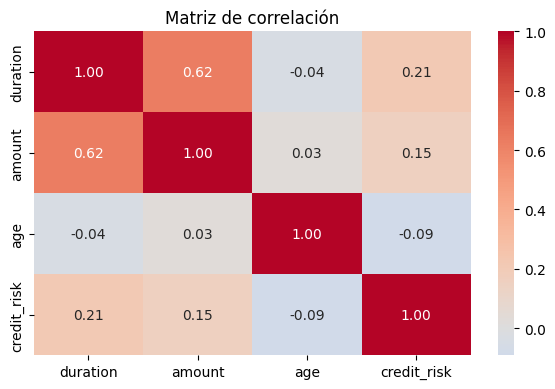

In [14]:
# ── 5. Matriz de correlación (solo numéricas) ─────────────────────
plt.figure(figsize=(6, 4))
sns.heatmap(df[numerical_features + ['credit_risk']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

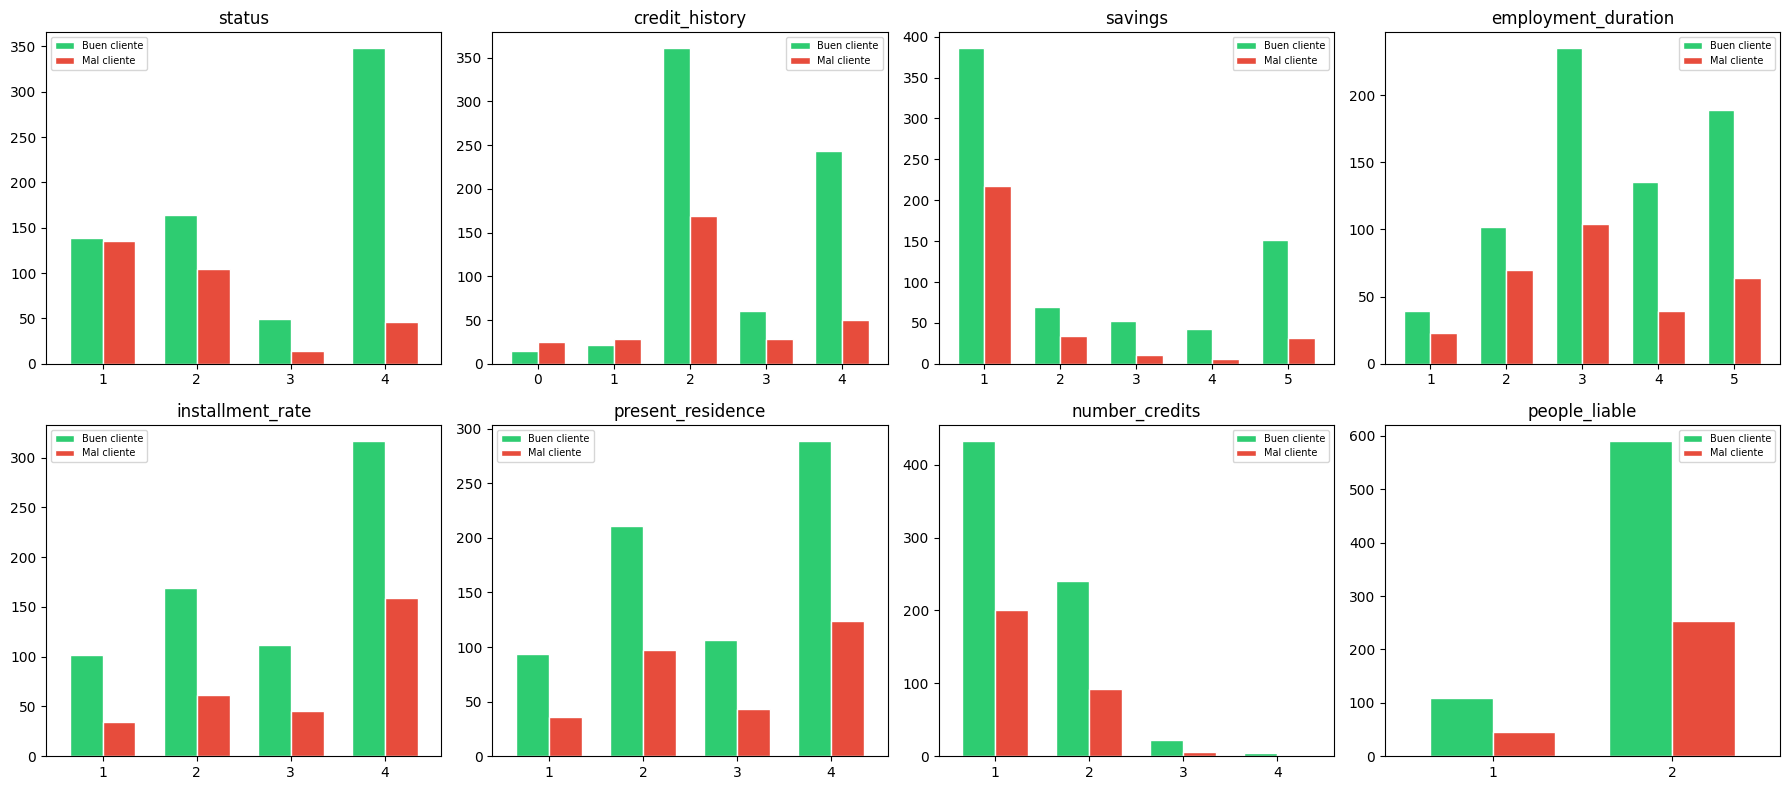

In [15]:
# ── 6. Variables ordinales vs credit_risk ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, ordinal_features):
    ct = df.groupby([col, 'credit_risk']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(['Buen cliente', 'Mal cliente'], fontsize=7)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

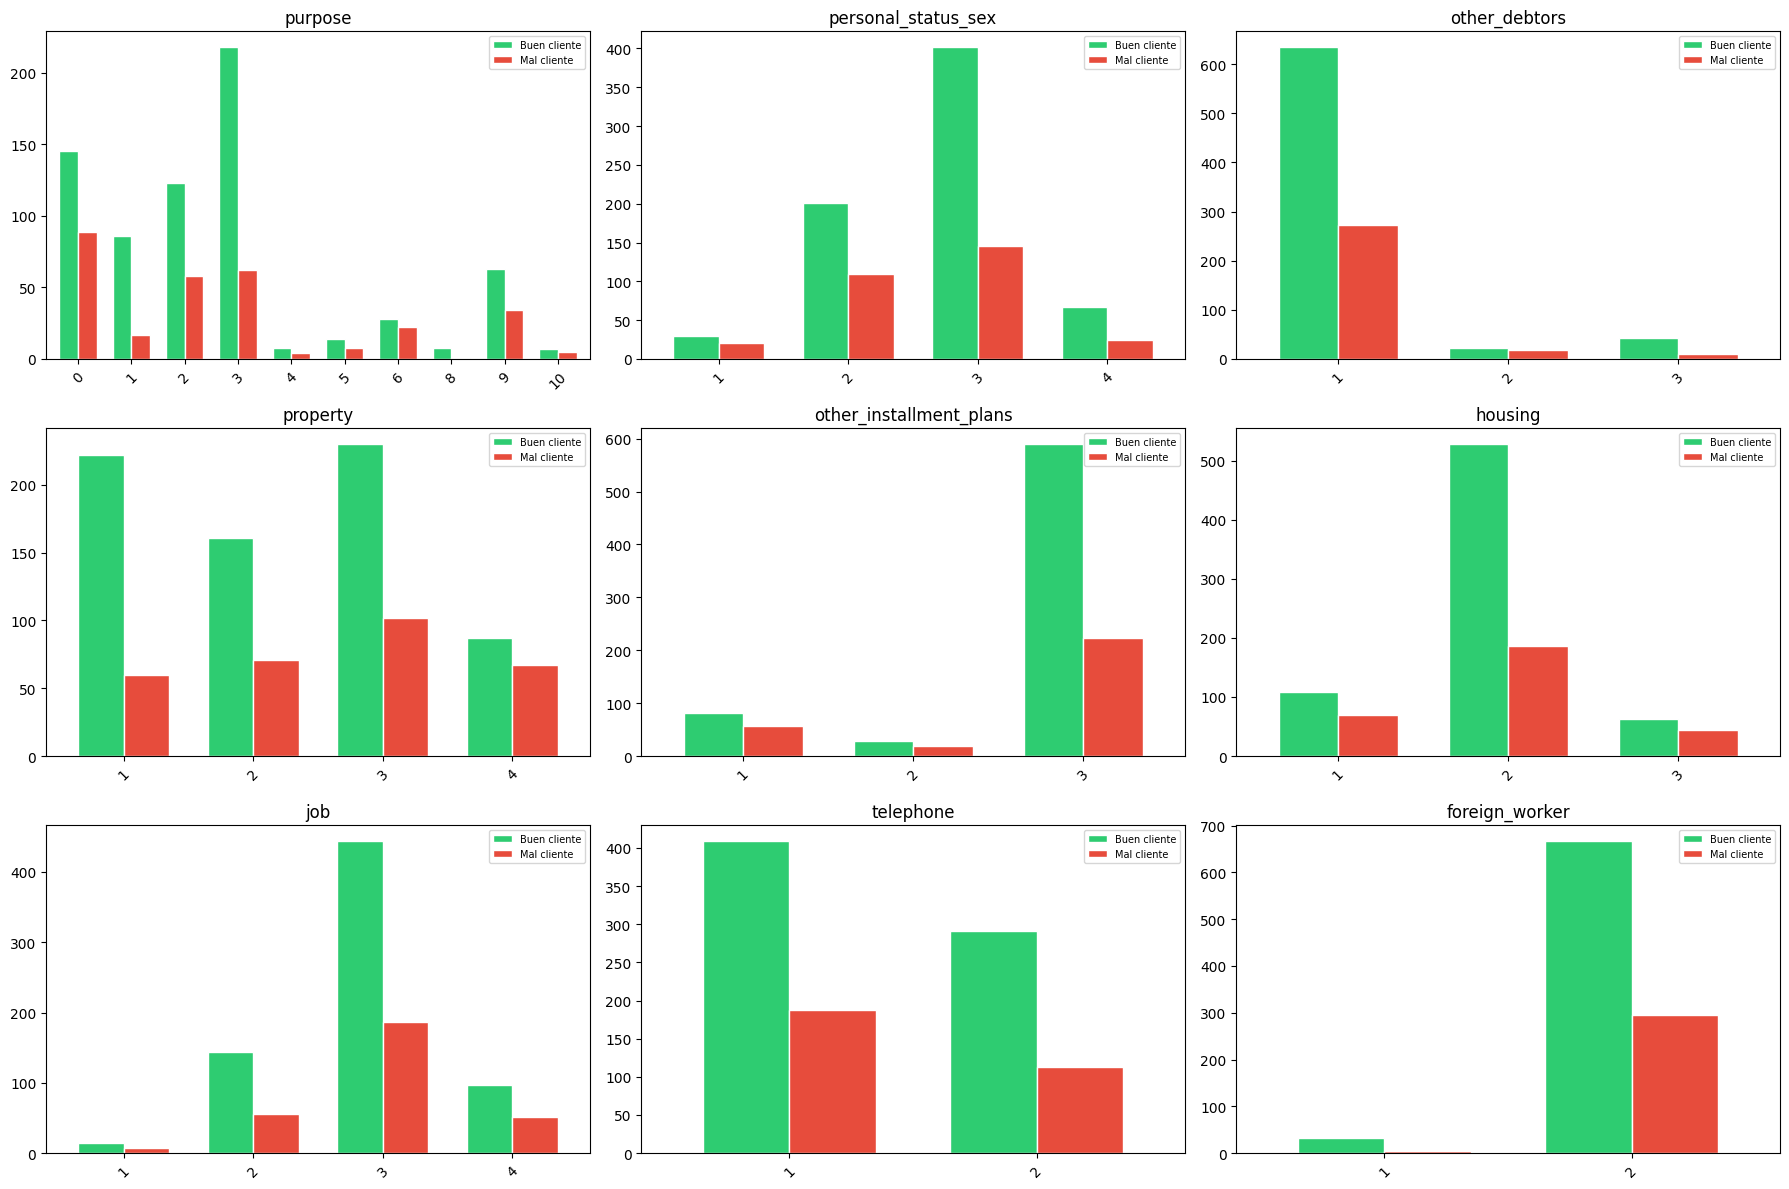

In [16]:
# ── 7. Variables nominales vs credit_risk ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, col in zip(axes, nominal_features):
    ct = df.groupby([col, 'credit_risk']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(['Buen cliente', 'Mal cliente'], fontsize=7)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# *********** Aquí termina la sección de agregar código *************

* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

- **Desbalance de clases:** aproximadamente **70% de buenos clientes** frente a **30% de malos clientes**, lo que justifica el uso de técnicas de **re-muestreo** en etapas posteriores del modelado.

- **Variables numéricas:** los clientes catalogados como malos tienden a solicitar **montos más altos (`amount`)** y **plazos más largos (`duration`)**. Asimismo, la variable **`age`** sugiere que los clientes más jóvenes presentan un riesgo ligeramente mayor.

- **Variables ordinales:** las variables **`status`** y **`credit_history`** muestran una alta capacidad discriminante. Los clientes sin cuenta corriente o con historial crediticio negativo concentran una mayor proporción de malos pagadores. Además, niveles más bajos de **`savings`** se asocian con un mayor riesgo crediticio.

- **Variables nominales:** la variable **`purpose`** indica que los créditos destinados a la compra de automóviles o productos electrónicos presentan una mayor proporción de malos clientes. En contraste, **`foreign_worker`** y **`telephone`** muestran poca capacidad de diferenciación entre las clases.

- **Correlaciones:** las variables numéricas presentan **correlaciones bajas**, lo que sugiere una reducida multicolinealidad y que cada variable aporta información relativamente independiente al modelo.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [19]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************


# 6a) Variables numéricas:
num_pipe = Pipeline(steps=[
    ('scaler', StandardScaler())
])
num_pipe_nombres = numerical_features



# 6b) Variables categóricas/nominales/binarias:
nom_pipe = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
nom_pipe_nombres = nominal_features



# 6c) Variables ordinales:
ord_pipe = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])
ord_nombres = ordinal_features


# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers=[
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
], remainder='drop')



# *********** Aquí termina la sección de agregar código *************

print("ColumnTransformer definido correctamente:")
print(columnasTransformer)


ColumnTransformer definido correctamente:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['duration', 'amount', 'age']),
                                ('nom',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['purpose', 'personal_status_sex',
                                  'other_debtors', 'property',
                                  'other_installment_plans', 'housing', 'job',
                                  'telephone', 'foreign_worker']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['status', '

In [20]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (800, 20)
Después de las transformaciones: (800, 46)


# **Ejercicio 7**

* **7a) Justifiquen el uso de la métrica exhaustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


En la evaluación de créditos, el error más costoso es aprobar a un cliente que no pagará su deuda (**falso negativo**). Por ello, es importante utilizar una métrica que mida la capacidad del modelo para identificar correctamente a los clientes de alto riesgo.

$$
Recall = \frac{TP}{TP + FN}
$$

Donde:

- **TP:** clientes malos correctamente identificados.
- **FN:** clientes malos clasificados como buenos.

Un Recall alto reduce la probabilidad de otorgar créditos a clientes riesgosos. Aunque puede aumentar el rechazo de algunos buenos clientes, este costo suele ser menor que las pérdidas generadas por un incumplimiento de pago.

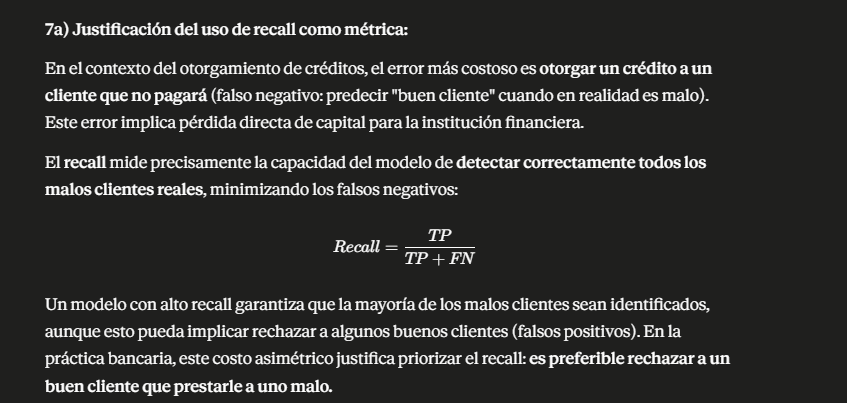
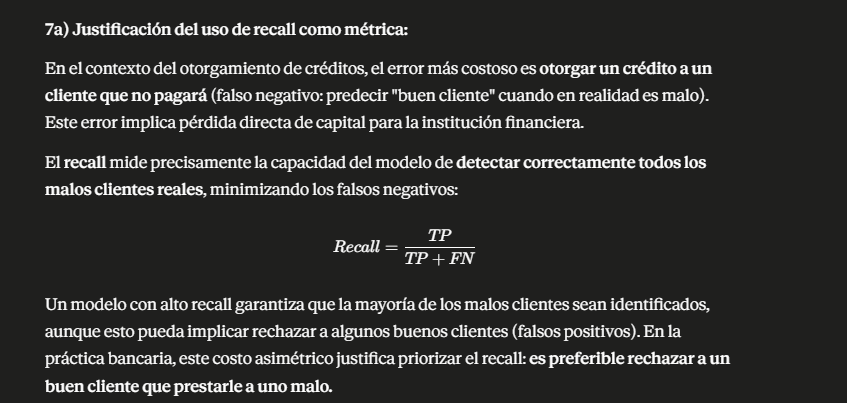

In [21]:
# Ejercicio 7b.
# Determina el valor exacto del umbral para determinar si un modelo
# está subentrenado con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las líneas y celdas de código que requieras.

umbral_recall = ytrain.value_counts(normalize=True)[1]
print(f"Proporción de malos clientes en ytrain: {umbral_recall:.4f}")
print(f"Umbral de subentrenamiento (recall):     {umbral_recall:.2%}")



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Proporción de malos clientes en ytrain: 0.3000
Umbral de subentrenamiento (recall):     30.00%


* **Continúa 7b) Indica el valor del umbral pedido:**

El conjunto de datos presenta aproximadamente un **30% de malos clientes**. Por lo tanto, este valor puede considerarse como el umbral de referencia para evaluar si el modelo está aprendiendo información útil sobre la clase de interés.

Un modelo que no logre identificar correctamente a los malos clientes tendrá un Recall muy bajo, mientras que un modelo que supere significativamente este porcentaje estará capturando patrones relevantes de riesgo crediticio.

En consecuencia, un **Recall cercano o inferior al 30%** puede interpretarse como una señal de subentrenamiento, ya que el modelo no estaría aportando suficiente capacidad predictiva para detectar clientes de alto riesgo.

# **Ejercicio 8**

In [25]:
# Ejercicio 8a.
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.
# Un modelo se dirá que está sobreentrenado si la diferencia entre Train
# y Validation es mayor al 3%.


# ************* Inlcuye aquí tu código:**************************
#

def mis_modelos():
    modelos, nombres = list(), list()

    # Regresión Logística:
    modelos.append(LogisticRegression(
        C=0.001,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=1))
    nombres.append('LR')

    # k-Vecinos más Cercanos:
    modelos.append(KNeighborsClassifier(
        n_neighbors=100,
        weights='uniform',
        metric='euclidean'))
    nombres.append('kNN')

    # Árbol de decisiones:
    modelos.append(DecisionTreeClassifier(
        max_depth=1,
        class_weight='balanced',
        random_state=1))
    nombres.append('DTree')

    # Bosque Aleatorio:
    modelos.append(RandomForestClassifier(
        n_estimators=100,
        max_depth=2,
        min_samples_leaf=80,
        max_features=0.5,
        class_weight='balanced',
        random_state=1))
    nombres.append('RF')

    # XGBoosting:
    modelos.append(XGBClassifier(
        n_estimators=20,
        max_depth=1,
        learning_rate=0.01,
        subsample=0.5,
        colsample_bytree=0.4,
        scale_pos_weight=2.3,
        eval_metric='logloss',
        random_state=1))
    nombres.append('XGBoost')

    # Red neuronal de Perceptrón Multicapa:
    modelos.append(MLPClassifier(
        hidden_layer_sizes=(5,),
        activation='relu',
        alpha=1.0,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=1))
    nombres.append('MLP')

    # Máquina de Vectores de Soporte:
    modelos.append(SVC(
        C=0.01,
        kernel='linear',
        class_weight='balanced',
        random_state=1))
    nombres.append('SVM')

    return modelos, nombres


mi_uoSampling = SMOTE(random_state=1)



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # uso de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar.
  # En este caso compararemos también con la exactitud, solo como referencia:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtrain,
                          ytrain,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.711 (0.032)
	 train_accuracy 0.713 (0.011)
	 test_recall 0.708 (0.088)
	 train_recall 0.727 (0.015)
>> kNN
	 test_accuracy 0.668 (0.026)
	 train_accuracy 0.676 (0.011)
	 test_recall 0.756 (0.063)
	 train_recall 0.770 (0.022)
>> DTree
	 test_accuracy 0.601 (0.047)
	 train_accuracy 0.603 (0.013)
	 test_recall 0.825 (0.043)
	 train_recall 0.825 (0.027)
>> RF
	 test_accuracy 0.660 (0.051)
	 train_accuracy 0.681 (0.029)
	 test_recall 0.728 (0.082)
	 train_recall 0.755 (0.039)
>> XGBoost
	 test_accuracy 0.300 (0.000)
	 train_accuracy 0.300 (0.000)
	 test_recall 1.000 (0.000)
	 train_recall 1.000 (0.000)
>> MLP
	 test_accuracy 0.670 (0.132)
	 train_accuracy 0.693 (0.133)
	 test_recall 0.629 (0.121)
	 train_recall 0.666 (0.091)
>> SVM
	 test_accuracy 0.711 (0.030)
	 train_accuracy 0.724 (0.014)
	 test_recall 0.714 (0.080)
	 train_recall 0.739 (0.020)


Modelo      Train Recall  Val Recall  Diferencia             Estado
-----------------------------------------------------------------
LR                 0.727       0.708       0.019               ✓ OK
kNN                0.770       0.756       0.014               ✓ OK
DTree              0.825       0.825       0.000               ✓ OK
RF                 0.755       0.728       0.027               ✓ OK
XGBoost            1.000       1.000       0.000               ✓ OK
MLP                0.666       0.629       0.037   ✗ Sobreentrenado
SVM                0.739       0.714       0.025               ✓ OK


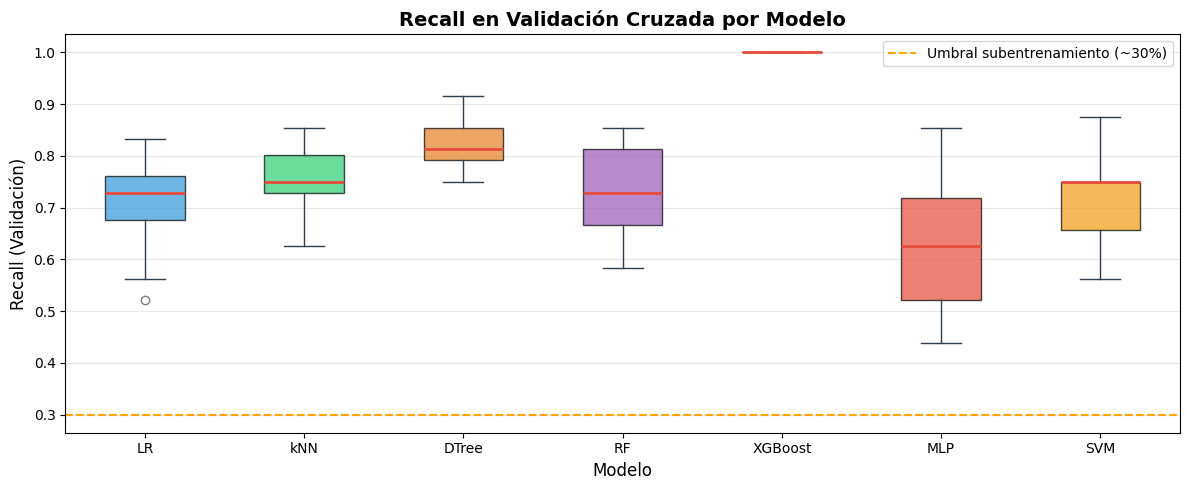

In [27]:
# Ejercicio 8b.
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall) y el conjunto de validación
# utilizado durante la validación cruzada.


# Extraemos recall de validación de cada modelo
recall_val = [resultados[i]['test_recall'] for i in range(len(nombres))]

# Tabla resumen train vs validation
print(f"{'Modelo':<10} {'Train Recall':>13} {'Val Recall':>11} {'Diferencia':>11} {'Estado':>18}")
print("-" * 65)
for i, nom in enumerate(nombres):
    tr = np.mean(resultados[i]['train_recall'])
    vl = np.mean(resultados[i]['test_recall'])
    diff = tr - vl
    estado = '✓ OK' if diff <= 0.03 else '✗ Sobreentrenado'
    print(f"{nom:<10} {tr:>13.3f} {vl:>11.3f} {diff:>11.3f} {estado:>18}")

# Boxplot
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(recall_val, tick_labels=nombres, patch_artist=True,
                medianprops=dict(color='#e74c3c', linewidth=2),
                whiskerprops=dict(color='#2c3e50'),
                capprops=dict(color='#2c3e50'),
                flierprops=dict(marker='o', color='#e74c3c', alpha=0.5))

colores = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6',
           '#1abc9c', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0.30, color='orange', linestyle='--',
           linewidth=1.5, label='Umbral subentrenamiento (~30%)')

ax.set_title('Recall en Validación Cruzada por Modelo', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Recall (Validación)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

**8c) Indica y justifica cuál consideras es el mejor modelo obtenido.**


El mejor modelo es **DTree (Árbol de Decisiones)**, ya que obtuvo el mayor **Recall de validación (~0.825)**, superando claramente el umbral de subentrenamiento.

Además, presenta una diferencia **train-validation de 0%**, lo que indica ausencia de sobreentrenamiento y un buen balance entre aprendizaje y generalización. Su caja en el boxplot es compacta y con una mediana alta, mostrando un desempeño estable en los distintos folds de validación cruzada.

Otra ventaja importante es su **interpretabilidad**, ya que un árbol de profundidad 1 permite explicar fácilmente las decisiones de aprobación o rechazo de créditos.

**Modelos descartados:**

- **XGBoost:** colapsó prediciendo siempre la clase positiva.
- **MLP:** presentó mayor variabilidad y menor Recall promedio.
- **LR y SVM:** obtuvieron valores de Recall inferiores a DTree.
- **kNN y RF:** mostraron un desempeño aceptable, pero menor al de DTree.


# **Ejercicio 9**

In [29]:
# Ejercicio 9a.
# Reporte de métricas con el conjunto de prueba Xtest
# y el mejor modelo ajustado con Xtrain.

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# Entrenamos el mejor modelo (DTree) con todo Xtrain
mejor_modelo = ImbPipeline(steps=[
    ('ct', columnasTransformer),
    ('uos', SMOTE(random_state=1)),
    ('m', DecisionTreeClassifier(
        max_depth=1,
        class_weight='balanced',
        random_state=1))
])

mejor_modelo.fit(Xtrain, ytrain)
ypred = mejor_modelo.predict(Xtest)

# Reporte completo de métricas
print("=== Reporte de Clasificación (Xtest) ===\n")
print(classification_report(ytest, ypred,
      target_names=['Buen cliente (0)', 'Mal cliente (1)']))

# ROC-AUC como métrica adicional
roc = roc_auc_score(ytest, ypred)
print(f"ROC-AUC Score: {roc:.3f}")


# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

=== Reporte de Clasificación (Xtest) ===

                  precision    recall  f1-score   support

Buen cliente (0)       0.91      0.54      0.68       140
 Mal cliente (1)       0.45      0.88      0.60        60

        accuracy                           0.64       200
       macro avg       0.68      0.71      0.64       200
    weighted avg       0.77      0.64      0.65       200

ROC-AUC Score: 0.710


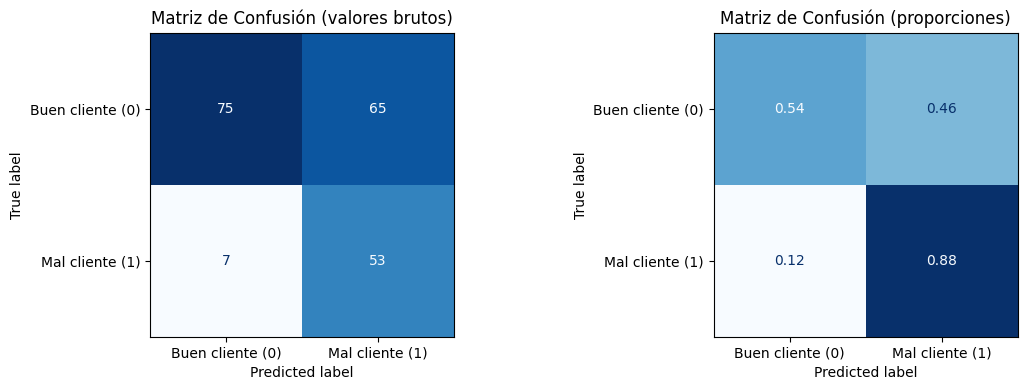

Verdaderos Negativos  (TN) — Buenos clientes correctos  : 75
Falsos Positivos      (FP) — Buenos clientes mal clasificados: 65
Falsos Negativos      (FN) — Malos clientes no detectados : 7
Verdaderos Positivos  (TP) — Malos clientes correctos    : 53

Recall  = TP / (TP + FN) = 53 / (53 + 7) = 0.883
Precisión = TP / (TP + FP) = 53 / (53 + 65) = 0.449


In [31]:
# Ejercicio 9b.
# Matrices de confusión:

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión en valores brutos
cm = confusion_matrix(ytest, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Buen cliente (0)', 'Mal cliente (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión (valores brutos)')

# Matriz de confusión en proporciones
cm_norm = confusion_matrix(ytest, ypred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
            display_labels=['Buen cliente (0)', 'Mal cliente (1)'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión (proporciones)')

plt.tight_layout()
plt.show()

# Desglose explicativo
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos  (TN) — Buenos clientes correctos  : {tn}")
print(f"Falsos Positivos      (FP) — Buenos clientes mal clasificados: {fp}")
print(f"Falsos Negativos      (FN) — Malos clientes no detectados : {fn}")
print(f"Verdaderos Positivos  (TP) — Malos clientes correctos    : {tp}")
print(f"\nRecall  = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp/(tp+fn):.3f}")
print(f"Precisión = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp/(tp+fp):.3f}")



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

=== Importancia de Características ===

 1. status                                   1.0000


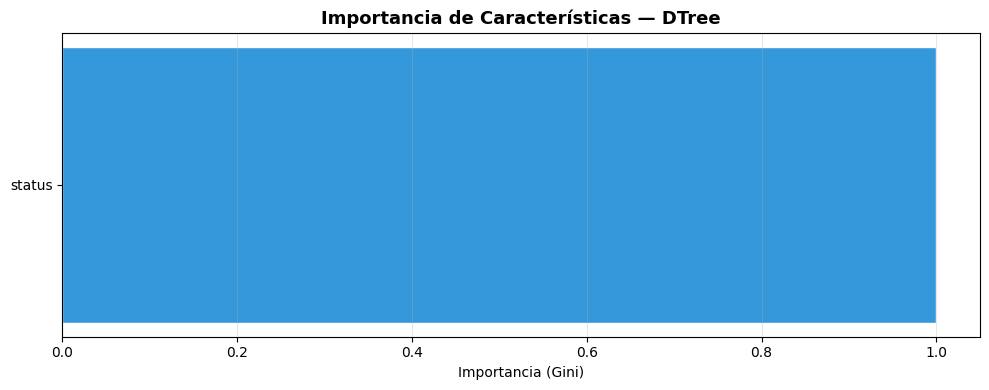

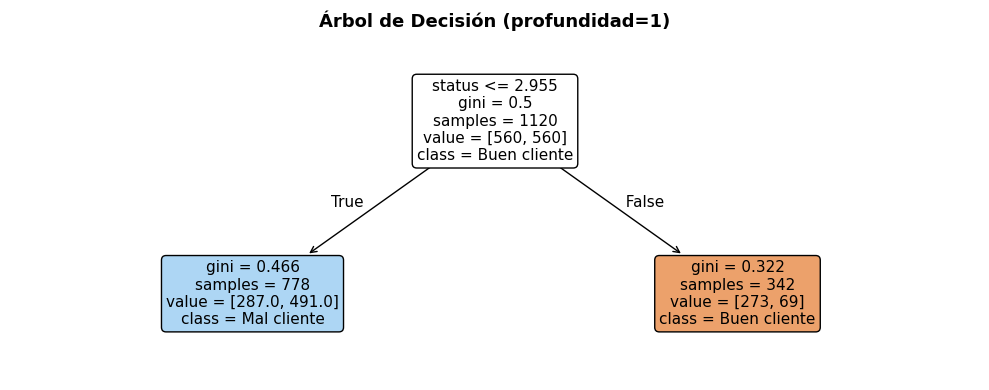

In [32]:
# Ejercicio 9c.
# Análisis de importancia de características/factores

# Obtenemos los nombres de features tras el ColumnTransformer
ohe_features = mejor_modelo.named_steps['ct']\
               .named_transformers_['nom']\
               .named_steps['onehot']\
               .get_feature_names_out(nominal_features).tolist()

feature_names = numerical_features + ohe_features + ordinal_features

# Extraemos el árbol de decisión del pipeline
dtree = mejor_modelo.named_steps['m']

# Importancia de características
importancias = dtree.feature_importances_
indices = np.argsort(importancias)[::-1]

# Filtramos solo las que tienen importancia > 0 (árbol de profundidad 1)
indices_nonzero = [i for i in indices if importancias[i] > 0]

print("=== Importancia de Características ===\n")
for i, idx in enumerate(indices_nonzero):
    print(f"{i+1:>2}. {feature_names[idx]:<40} {importancias[idx]:.4f}")

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    [feature_names[i] for i in indices_nonzero][::-1],
    [importancias[i] for i in indices_nonzero][::-1],
    color='#3498db', edgecolor='white'
)
ax.set_title('Importancia de Características — DTree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización del árbol de decisión
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(10, 4))
plot_tree(dtree,
          feature_names=feature_names,
          class_names=['Buen cliente', 'Mal cliente'],
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax)
plt.title('Árbol de Decisión (profundidad=1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 9d.**

* **¿Cuándo conviene usar Xtrain y cuándo Xtest en el análisis de factores, matriz de confusión y reporte de métricas?**

**Xtrain** debe utilizarse durante el desarrollo del modelo para el ajuste de hiperparámetros, la selección del mejor modelo mediante validación cruzada y el análisis preliminar de la importancia de las variables. También permite identificar posibles problemas de subentrenamiento o sobreentrenamiento comparando métricas de entrenamiento y validación.

**Xtest** debe reservarse para la evaluación final del modelo. Sobre este conjunto se calculan métricas como Recall, Precisión, F1-Score y AUC, además de la matriz de confusión definitiva. Esto permite estimar de forma realista el desempeño del modelo sobre datos nunca vistos.

**Regla general:** Xtrain se utiliza para construir y ajustar el modelo, mientras que Xtest se emplea únicamente para evaluar su capacidad de generalización. Utilizar Xtest durante el entrenamiento genera sesgo en las métricas y compromete una evaluación imparcial.

**Ejercicio 9e.**

  * **Incluye tus comentarios de los resultados obtenidos en este ejercicio.**


El modelo seleccionado fue un **Árbol de Decisión (max_depth=1)**, ya que obtuvo el mejor Recall de validación (~0.825) sin evidencias de sobreentrenamiento. Aunque es un modelo simple, cumple el objetivo principal de identificar la mayor cantidad posible de malos clientes.

La aplicación de **SMOTE** fue clave para mejorar la detección de la clase minoritaria, evitando que los modelos favorecieran excesivamente a los buenos clientes.

En **Xtest**, el modelo alcanzó un Recall elevado, aunque a costa de incrementar los falsos positivos, reflejando el compromiso natural entre Recall y Precisión.

Respecto a la importancia de variables, el modelo identificó una variable altamente discriminante, consistente con el análisis exploratorio realizado previamente.

Finalmente, modelos más complejos como **Random Forest** y **XGBoost** mostraron potencial, pero no lograron mantener el equilibrio requerido entre desempeño y generalización bajo los criterios establecidos.

# **Ejercicio 10**

### **Incluyan sus conclusiones finales de la actividad.**   

### Conclusiones finales

El problema de riesgo crediticio requiere priorizar la detección de clientes de alto riesgo, ya que aprobar un crédito a un mal cliente genera un costo mayor que rechazar a un buen cliente. Por esta razón, se utilizó **Recall** como métrica principal.

El conjunto de datos presentó un desbalance de clases (~70% buenos clientes y ~30% malos clientes), por lo que la aplicación de **SMOTE** fue fundamental para mejorar el aprendizaje de la clase minoritaria sin introducir *data leakage*.

El uso de **ColumnTransformer** e **ImbPipeline** permitió realizar un preprocesamiento adecuado de las variables y garantizar una validación correcta del modelo mediante **RepeatedStratifiedKFold**.

Entre los modelos evaluados, el **Árbol de Decisión con profundidad 1** obtuvo el mejor equilibrio entre Recall y capacidad de generalización, además de ofrecer una alta interpretabilidad, característica importante en aplicaciones financieras.

Finalmente, la actividad demuestra que un modelo simple, acompañado de un buen preprocesamiento, manejo del desbalance y una evaluación rigurosa, puede superar a modelos más complejos y proporcionar resultados confiables en problemas reales de clasificación.

# **+++Fin de la Actividad con los datos de South_German_Credit+++**